<a href="https://colab.research.google.com/github/sametgumusaydin/data_mining-AI/blob/main/data_mining_Apriori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BİRLİKTELİK KURALLARI (ASSOCIATION RULES)


Birlikte gerçekleşen olaylar arasındaki ilişkileri keşfetmek

Yani:


“Bu ürünü alan bunu da alır”
“Bu davranışı yapan bu davranışı da yapar”

***Problem nedir?

Verimiz şu tipte:

Müşteri	Sepet

1 ---->	süt, ekmek

2 ---->	süt, yumurta

3 ---->	ekmek, peynir


Ama şu yok:

etiket yok

hedef değişken yok


**** Ama yine de bilgi var!

*** Temel kavram


“Birlikte görülen öğeler arasında ilişki çıkarma”


malum en klasik örnek


Market Sepeti:


“Ekmek alan müşterilerin %70 i süt de alıyor”


Bu bir association rule dur


****---Kural yapısı----****

X→Y


Örnek:


{ekmek}→{süt}


temel metrik (EN KRİTİK KISIM)

** Support (Destek)


Bir ürün grubunun veri setinde görülme oranı


Support(X)=Xicerenişlemler/Toplamişlem




Confidence (Güven)

X varsa Y olma olasılığı

Confidence(X→Y)=Support(X∪Y)/Support(X)

Confidence(X→Y)=
Support(X)/
Support(X∪Y)
	​


Lift (EN ÖNEMLİSİ)

Bağımsızlığa göre ilişki gücü

Lift=ConfidenceSupport(Y)
Lift=
Support(Y)
Confidence
	​

?????--Lift yorumu---???


 =1	bağımsız

 .>1	pozitif ilişki

 <1	negatif ilişki


Algoritma: Apriori Mantık:


“Sık olmayan kombinasyonların alt kümeleri de sık değildir”


Bu sayede arama alanı küçülür

In [20]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [15]:
transactions = [
    ['ekmek', 'süt'],
    ['ekmek', 'yumurta'],
    ['süt', 'yumurta'],
    ['ekmek', 'süt', 'yumurta'],
    ['ekmek', 'süt'],
    ['süt', 'peynir'],
    ['ekmek', 'peynir'],
    ['süt', 'yumurta'],
    ['ekmek', 'süt', 'peynir'],
    ['ekmek', 'yumurta']
]

df = pd.DataFrame(transactions)

One-Hot Encoding

In [22]:
# 1) Transaction verisini binary matrise çevir
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print("=== One-Hot Encoded Veri ===")
print(df)
print()

=== One-Hot Encoded Veri ===
   ekmek  peynir    süt  yumurta
0   True   False   True    False
1   True   False  False     True
2  False   False   True     True
3   True   False   True     True
4   True   False   True    False
5  False    True   True    False
6   True    True  False    False
7  False   False   True     True
8   True    True   True    False
9   True   False  False     True



In [23]:
# 2) Frequent itemsets bul
frequent_items = apriori(df, min_support=0.3, use_colnames=True)

print("=== Frequent Itemsets ===")
print(frequent_items)
print()


=== Frequent Itemsets ===
   support          itemsets
0      0.7           (ekmek)
1      0.3          (peynir)
2      0.7             (süt)
3      0.5         (yumurta)
4      0.4      (süt, ekmek)
5      0.3  (yumurta, ekmek)
6      0.3    (yumurta, süt)



In [25]:
# 3) Association rules üret
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)

# 4) Sadece gerekli sütunları göster
if not rules.empty:
    rules = rules[["antecedents", "consequents", "support", "confidence", "lift"]]

    # frozenset görüntüsünü daha okunabilir hale getirme
    rules["antecedents"] = rules["antecedents"].apply(lambda x: ', '.join(list(x)))
    rules["consequents"] = rules["consequents"].apply(lambda x: ', '.join(list(x)))

    print("=== Association Rules ===")
    print(rules.sort_values(by=["lift", "confidence"], ascending=False))
else:
    print("Belirtilen eşik değerleriyle association rule bulunamadı.")

=== Association Rules ===
  antecedents consequents  support  confidence      lift
2     yumurta       ekmek      0.3    0.600000  0.857143
3     yumurta         süt      0.3    0.600000  0.857143
0         süt       ekmek      0.4    0.571429  0.816327
1       ekmek         süt      0.4    0.571429  0.816327


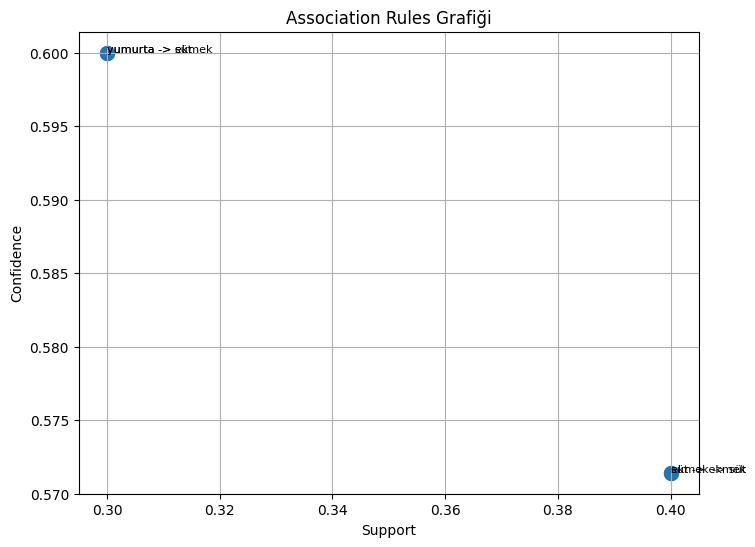

In [27]:
import matplotlib.pyplot as plt

if not rules.empty:
    plt.figure(figsize=(8, 6))
    plt.scatter(rules["support"], rules["confidence"], s=100)

    for i in range(len(rules)):
        plt.text(
            rules.iloc[i]["support"],
            rules.iloc[i]["confidence"],
            f'{rules.iloc[i]["antecedents"]} -> {rules.iloc[i]["consequents"]}',
            fontsize=8
        )

    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.title("Association Rules Grafiği")
    plt.grid(True)
    plt.show()